In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
import os

In [2]:
load_dotenv()

True

In [5]:
llm=ChatOpenAI(
    model="openai/gpt-oss-20b",   # Must support structured outputs
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [4]:
class JokeState(TypedDict):
    topic:str
    joke:str
    explanation:str

In [6]:
def generate_joke(state:JokeState):
    prompt=f'Generate a joke on the topic {state['topic']}'

    response=llm.invoke(prompt).content
    return {'joke':response}

In [7]:
def generate_explanation(state:JokeState):
    prompt=f"Generate a detail explanation about {state['joke']}"

    response=llm.invoke(prompt).content

    return {'explanation':response}

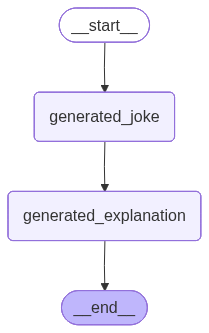

In [14]:
graph=StateGraph(JokeState)
graph.add_node('generated_joke',generate_joke)
graph.add_node('generated_explanation',generate_explanation)

# add edge
graph.add_edge(START,'generated_joke')
graph.add_edge('generated_joke','generated_explanation')
graph.add_edge('generated_explanation',END)

checkpointer=InMemorySaver()
chatbot=graph.compile(checkpointer=checkpointer)
chatbot

In [15]:
config1={'configurable':{'thread_id':1}}
chatbot.invoke({'topic':'pizza'},config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '## Why Did the Pizza Apply for a Job?  \n*Because it wanted to get a **crust** of a living!* 🍕😄  \n\nBelow is a deep‑dive into the joke, its linguistic mechanics, cultural context, and why it tickles our funny bone.\n\n---\n\n### 1. The Core of the Joke\n\n| Element | Explanation |\n|---------|-------------|\n| **Pizza** | A food item that is *inanimate* but anthropomorphized (given human traits). |\n| **Job Application** | A human activity that requires motivation, ambition, and a need for income. |\n| **Pun: “crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* replaces *cost*, tying back to a pizza’s defining feature. |\n\nThe humor arises from the absurdity of a pizza—an object that cannot think or work—taking on a human goal (earning a living) and doing so in a way that cleverly references its own anatomy.\n\n---\n\n

In [17]:
chatbot.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why Did the Pizza Apply for a Job?  \n*Because it wanted to get a **crust** of a living!* 🍕😄  \n\nBelow is a deep‑dive into the joke, its linguistic mechanics, cultural context, and why it tickles our funny bone.\n\n---\n\n### 1. The Core of the Joke\n\n| Element | Explanation |\n|---------|-------------|\n| **Pizza** | A food item that is *inanimate* but anthropomorphized (given human traits). |\n| **Job Application** | A human activity that requires motivation, ambition, and a need for income. |\n| **Pun: “crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* replaces *cost*, tying back to a pizza’s defining feature. |\n\nThe humor arises from the absurdity of a pizza—an object that cannot think or work—taking on a human goal (earning a living) and doing so in a way that cleverly references its own 

In [18]:

list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why Did the Pizza Apply for a Job?  \n*Because it wanted to get a **crust** of a living!* 🍕😄  \n\nBelow is a deep‑dive into the joke, its linguistic mechanics, cultural context, and why it tickles our funny bone.\n\n---\n\n### 1. The Core of the Joke\n\n| Element | Explanation |\n|---------|-------------|\n| **Pizza** | A food item that is *inanimate* but anthropomorphized (given human traits). |\n| **Job Application** | A human activity that requires motivation, ambition, and a need for income. |\n| **Pun: “crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* replaces *cost*, tying back to a pizza’s defining feature. |\n\nThe humor arises from the absurdity of a pizza—an object that cannot think or work—taking on a human goal (earning a living) and doing so in a way that cleverly references its own

In [19]:

config2 = {"configurable": {"thread_id": "2"}}
chatbot.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it couldn’t stop feeling *tortellini*—it was always *twisted* in its own noodles!',
 'explanation': '**Why the Spaghetti Went to Therapy – A Deep‑Dive into Pasta‑Psychology**\n\nPicture a long, slender strand of spaghetti, glistening under the kitchen light, dreaming of a life beyond the pot. It’s a classic, unassuming noodle, but beneath its humble exterior lies a tangled web of emotions that only a seasoned therapist could untangle. Here’s a detailed, tongue‑in‑cheek exploration of why this particular strand of spaghetti sought professional help.\n\n---\n\n### 1. The “Tortellini” Identity Crisis\n\n**The Root of the Problem**  \nThe joke’s punchline hinges on the word *tortellini*, a small, ring‑shaped pasta that’s often stuffed with cheese or meat. In the world of pasta, *tortellini* is the embodiment of “stuffed” and “full of surprises.” For our spaghetti, the term *tortellini* becomes a metaphor for feeli

In [20]:
chatbot.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why Did the Pizza Apply for a Job?  \n*Because it wanted to get a **crust** of a living!* 🍕😄  \n\nBelow is a deep‑dive into the joke, its linguistic mechanics, cultural context, and why it tickles our funny bone.\n\n---\n\n### 1. The Core of the Joke\n\n| Element | Explanation |\n|---------|-------------|\n| **Pizza** | A food item that is *inanimate* but anthropomorphized (given human traits). |\n| **Job Application** | A human activity that requires motivation, ambition, and a need for income. |\n| **Pun: “crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* replaces *cost*, tying back to a pizza’s defining feature. |\n\nThe humor arises from the absurdity of a pizza—an object that cannot think or work—taking on a human goal (earning a living) and doing so in a way that cleverly references its own 

In [21]:

list(chatbot.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '## Why Did the Pizza Apply for a Job?  \n*Because it wanted to get a **crust** of a living!* 🍕😄  \n\nBelow is a deep‑dive into the joke, its linguistic mechanics, cultural context, and why it tickles our funny bone.\n\n---\n\n### 1. The Core of the Joke\n\n| Element | Explanation |\n|---------|-------------|\n| **Pizza** | A food item that is *inanimate* but anthropomorphized (given human traits). |\n| **Job Application** | A human activity that requires motivation, ambition, and a need for income. |\n| **Pun: “crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* replaces *cost*, tying back to a pizza’s defining feature. |\n\nThe humor arises from the absurdity of a pizza—an object that cannot think or work—taking on a human goal (earning a living) and doing so in a way that cleverly references its own

Time Travel

In [23]:
chatbot.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1810a8-8a21-6bbd-8000-567330c2422e"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generated_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1810a8-8a21-6bbd-8000-567330c2422e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-16T11:36:06.717697+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1810a8-8a0e-6b0a-bfff-aeb8c76d4de6'}}, tasks=(PregelTask(id='2102c8bf-01be-5ef6-d56d-3260c8d4f122', name='generated_joke', path=('__pregel_pull', 'generated_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}),), interrupts=())